In [8]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.utils import shuffle
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import BatchNormalization
from keras.layers import Input, Lambda, Dense, Flatten, Activation, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.optimizers import RMSprop
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras import applications

In [36]:
train_datagen = ImageDataGenerator(
    rescale =1./255,
    rotation_range = 20,
    width_shift_range = 0.2,
    height_shift_range = 0.2,
    shear_range = 0.2,
    zoom_range = 0.2,
    horizontal_flip = True,
    fill_mode ='nearest',
    brightness_range=[0.8, 1.2], 
    channel_shift_range=30.0,
    validation_split = 0.2
)

valid_datagen = ImageDataGenerator(
    rescale = 1./255,
    validation_split = 0.2
)

train_generator = train_datagen.flow_from_directory(
    '/kaggle/input/cleandataset/dataset',
    target_size = (224,224),
    batch_size = 64,
    class_mode = 'categorical',
    subset = 'training'
)

validation_generator = valid_datagen.flow_from_directory(
    '/kaggle/input/cleandataset/dataset',
    target_size = (224,224),
    batch_size = 64,
    class_mode = 'categorical',
    subset = 'validation',
    shuffle = False
)

Found 16689 images belonging to 10 classes.
Found 4167 images belonging to 10 classes.


In [37]:
print("Tên lớp từ train_generator:")
for class_name, class_index in train_generator.class_indices.items():
    print(f"Chỉ số lớp: {class_index}, Tên lớp: {class_name}")

print("\nTên lớp từ validation_generator:")
for class_name, class_index in validation_generator.class_indices.items():
    print(f"Chỉ số lớp: {class_index}, Tên lớp: {class_name}")


Tên lớp từ train_generator:
Chỉ số lớp: 0, Tên lớp: butterfly
Chỉ số lớp: 1, Tên lớp: cat
Chỉ số lớp: 2, Tên lớp: chicken
Chỉ số lớp: 3, Tên lớp: cow
Chỉ số lớp: 4, Tên lớp: dog
Chỉ số lớp: 5, Tên lớp: elephant
Chỉ số lớp: 6, Tên lớp: horse
Chỉ số lớp: 7, Tên lớp: sheep
Chỉ số lớp: 8, Tên lớp: spider
Chỉ số lớp: 9, Tên lớp: squirrel

Tên lớp từ validation_generator:
Chỉ số lớp: 0, Tên lớp: butterfly
Chỉ số lớp: 1, Tên lớp: cat
Chỉ số lớp: 2, Tên lớp: chicken
Chỉ số lớp: 3, Tên lớp: cow
Chỉ số lớp: 4, Tên lớp: dog
Chỉ số lớp: 5, Tên lớp: elephant
Chỉ số lớp: 6, Tên lớp: horse
Chỉ số lớp: 7, Tên lớp: sheep
Chỉ số lớp: 8, Tên lớp: spider
Chỉ số lớp: 9, Tên lớp: squirrel


In [11]:
class_counts = np.bincount(train_generator.classes)
print(dict(enumerate(class_counts)))

{0: 1807, 1: 1668, 2: 2588, 3: 1866, 4: 2588, 5: 1446, 6: 2623, 7: 1820, 8: 2588, 9: 1862}


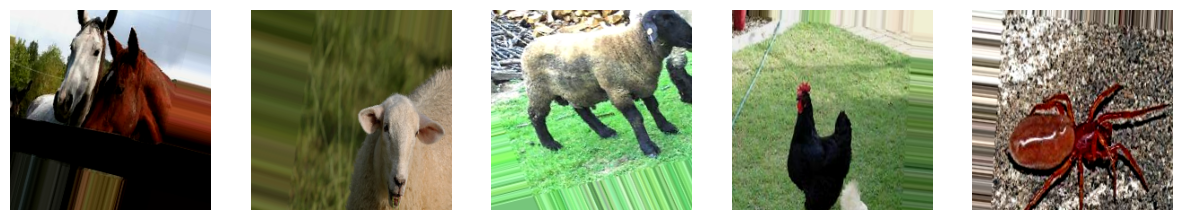

In [12]:
fig, ax = plt.subplots(nrows=1, ncols=5, figsize=(15,15))

for i in range(5):
    image = next(train_generator)[0][0]
    image = np.squeeze(image)
    ax[i].imshow(image)
    ax[i].axis(False)

In [13]:
from tensorflow.keras import models
from tensorflow.keras.models import Sequential
from tensorflow.keras import regularizers

In [77]:
# model = models.Sequential([
#     layers.Input(shape=(224, 224, 3)),
    
#     # Lớp Conv2D 32 filters
#     layers.Conv2D(32, (3, 3), activation='relu', padding='same', kernel_regularizer=regularizers.l2(0.0001)),
#     layers.BatchNormalization(),
#     layers.MaxPooling2D((2, 2), strides=2),
#     layers.Dropout(0.1),

#     # Lớp Conv2D 64 filters
#     layers.Conv2D(64, (3, 3), activation='relu', padding='same', kernel_regularizer=regularizers.l2(0.0001)),
#     layers.BatchNormalization(),
#     layers.MaxPooling2D((2, 2), strides=2),
#     layers.Dropout(0.1),

#     # Lớp Conv2D 128 filters
#     layers.Conv2D(128, (3, 3), activation='relu', padding='same', kernel_regularizer=regularizers.l2(0.0001)),
#     layers.BatchNormalization(),
#     layers.MaxPooling2D((2, 2), strides=2),
#     layers.Dropout(0.1),  

#     # Lớp Conv2D 256 filters mới thêm vào
#     layers.Conv2D(256, (3, 3), activation='relu', padding='same', kernel_regularizer=regularizers.l2(0.0001)),
#     layers.BatchNormalization(),
#     layers.MaxPooling2D((2, 2), strides=2),
#     layers.Dropout(0.1), 

# #     # GlobalAveragePooling2D
# #     layers.GlobalAveragePooling2D(),
#     layers.Flatten(),
#     # Dense layers
# #     layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
# #     layers.Dropout(0.2),
#     layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
#     layers.Dropout(0.1),
#     layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
#     layers.Dropout(0.1),

#     # Output layer
#     layers.Dense(10, activation='softmax')
# ])


In [78]:
#  model = models.Sequential([
#     layers.Input(shape=(224, 224, 3)),
#     layers.Conv2D(32, (5, 5), activation='relu',padding='same', strides=1),
#     layers.BatchNormalization(),
#     layers.MaxPooling2D((2, 2), strides=2),
#     layers.Dropout(0.1),
    

#     layers.Conv2D(64, (5, 5), activation='relu', padding='same', strides=1),
#     layers.BatchNormalization(),
#     layers.MaxPooling2D((2, 2), strides=2),
#     layers.Dropout(0.1),

#     layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
#     layers.BatchNormalization(),
#     layers.MaxPooling2D((2, 2), strides=2),
#     layers.Dropout(0.1),
     
#     layers.Flatten(),
#     layers.Dense(128, activation='relu'),
#     layers.Dense(64, activation='relu'),
#     layers.Dense(10, activation='softmax')
# ])

In [79]:
# optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)
# model.compile(optimizer=optimizer,
#               loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
#               metrics=['accuracy'])

# model.summary()

In [13]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers

model = models.Sequential([
    layers.InputLayer(shape=(224,224, 3)),
    layers.Conv2D(16, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(2048, activation='relu'),
    layers.Dense(512, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(10, activation='softmax')
])

optimizer = keras.optimizers.Adam(learning_rate=0.0001)
model.compile(
    optimizer=optimizer, loss="categorical_crossentropy", metrics=['accuracy', 'precision']
)
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 43264)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 2048)           │    88,606,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 89,749,514 (342.37 MB)

 Trainable params: 89,749,514 (342.37 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
print('Initial Layer Weights')
print()
for i in range(1, len(model.layers)):
    layer_weights = model.layers[i].get_weights()
    if layer_weights: 
        print('Weight for Layer '+str(i)+': ')
        print(layer_weights[0])
    else:
        print(f'Layer {i} does not have any weights.')
    print()


Initial Layer Weights

Layer 1 does not have any weights.

Weight for Layer 2: 
[[[[ 0.11470846 -0.06745811  0.04626844 ...  0.03282084  0.01661735
    -0.02140102]
   [-0.11636332 -0.11004604  0.04102998 ...  0.06575327 -0.03557835
     0.00649104]
   [-0.05624643  0.06528904 -0.08802268 ...  0.1176751  -0.10993446
    -0.00481194]
   ...
   [-0.11158901 -0.09181902  0.1061598  ...  0.1177213   0.02111588
    -0.00744319]
   [-0.00562618  0.02777601 -0.11588557 ...  0.041809    0.05218216
     0.05607105]
   [-0.04644877 -0.02135081  0.01515061 ... -0.09875156 -0.11742561
     0.0485925 ]]

  [[ 0.00636603 -0.08661795  0.09548914 ... -0.07378787  0.01112131
     0.04662416]
   [ 0.04821145 -0.02604588  0.02798008 ...  0.00930177  0.05180309
    -0.04737334]
   [-0.11051584  0.01085956  0.06430376 ...  0.11613093 -0.05086035
    -0.09912079]
   ...
   [ 0.07429332  0.01701162  0.02816587 ...  0.04055414 -0.05686498
    -0.0267669 ]
   [-0.10939664  0.06184929 -0.08673507 ...  0.0364056

In [38]:
from tensorflow.keras import models, Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout
import tensorflow as tf

# Tải mô hình VGG16
base_model = tf.keras.applications.VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
# base_model.trainable = False

# Xây dựng mô hình
model = Sequential()

# Sử dụng base_model thay cho conv_base
model.add(base_model) 
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.1))

model.add(Dense(120, activation='relu'))
model.add(Dropout(0.1))

model.add(Dense(32, activation='relu'))
model.add(Dropout(0.1))

model.add(Dense(10, activation='softmax'))

optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)
model.compile(optimizer=optimizer,
              loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
              metrics=['accuracy'])

model.build((None, 224, 224, 3))
model.summary(expand_nested=True)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ input_layer_6 (InputLayer) │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ block1_conv1 (Conv2D)      │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ block1_conv2 (Conv2D)      │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ block1_pool (MaxPooling2D) │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ block2_conv1 (Conv2D)      │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ block2_conv2 (Conv2D)      │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ block2_pool (MaxPooling2D) │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ block3_conv1 (Conv2D)      │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ block3_conv2 (Conv2D)      │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ block3_conv3 (Conv2D)      │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ block3_pool (MaxPooling2D) │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ block4_conv1 (Conv2D)      │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ block4_conv2 (Conv2D)      │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ block4_conv3 (Conv2D)      │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ block4_pool (MaxPooling2D) │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ block5_conv1 (Conv2D)      │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ block5_conv2 (Conv2D)      │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ block5_conv3 (Conv2D)      │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ block5_pool (MaxPooling2D) │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 120)            │        30,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 120)            │             

 Total params: 21,172,514 (80.77 MB)

 Trainable params: 21,172,514 (80.77 MB)

 Non-trainable params: 0 (0.00 B)

In [39]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.utils import class_weight
import numpy as np

early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5)

model_checkpoint = ModelCheckpoint('animal_classifier_no_freez_epoch_{epoch:02d}.keras', 
                                   monitor='val_loss', 
                                   save_best_only=True, 
                                   save_weights_only=False, 
                                   mode='auto', 
                                   save_freq='epoch')

class_weights_array = class_weight.compute_class_weight(class_weight='balanced',
                                                        classes=np.unique(train_generator.classes),
                                                        y=train_generator.classes)

class_weights = dict(enumerate(class_weights_array))

history = model.fit(
    train_generator,
    epochs=20,
    validation_data=validation_generator,
    callbacks=[early_stopping, reduce_lr, model_checkpoint],
    class_weight=class_weights  
)

model.save('animal_classifier_final_myteam.h5')

Epoch 1/20


/opt/conda/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


261/261 ━━━━━━━━━━━━━━━━━━━━ 387s 1s/step - accuracy: 0.1530 - loss: 2.2679 - val_accuracy: 0.3705 - val_loss: 1.8587 - learning_rate: 1.0000e-04
Epoch 2/20
261/261 ━━━━━━━━━━━━━━━━━━━━ 302s 1s/step - accuracy: 0.3919 - loss: 1.8231 - val_accuracy: 0.7202 - val_loss: 1.2174 - learning_rate: 1.0000e-04
Epoch 3/20
261/261 ━━━━━━━━━━━━━━━━━━━━ 271s 1s/step - accuracy: 0.6804 - loss: 1.2955 - val_accuracy: 0.7977 - val_loss: 1.0363 - learning_rate: 1.0000e-04
Epoch 4/20
261/261 ━━━━━━━━━━━━━━━━━━━━ 288s 1s/step - accuracy: 0.7760 - loss: 1.0793 - val_accuracy: 0.8452 - val_loss: 0.9035 - learning_rate: 1.0000e-04
Epoch 5/20
261/261 ━━━━━━━━━━━━━━━━━━━━ 272s 1s/step - accuracy: 0.8440 - loss: 0.9412 - val_accuracy: 0.8798 - val_loss: 0.8219 - learning_rate: 1.0000e-04
Epoch 6/20
261/261 ━━━━━━━━━━━━━━━━━━━━ 269s 1s/step - accuracy: 0.8722 - loss: 0.8652 - val_accuracy: 0.8721 - val_loss: 0.8224 - learning_rate: 1.0000e-04
Epoch 7/20
261/261 ━━━━━━━━━━━━━━━━━━━━ 286s 1s/step - accuracy: 0.89

In [40]:
import numpy as np
from sklearn.metrics import classification_report, accuracy_score
from tensorflow.keras import models

# Tải mô hình đã huấn luyện
my_model = models.load_model('/kaggle/working/animal_classifier_no_freez_epoch_20.keras')

# Dự đoán trên tập dữ liệu kiểm tra (validation_generator)
predictions = my_model.predict(validation_generator)

# Chuyển đổi các xác suất thành nhãn lớp dự đoán
predicted_classes = np.argmax(predictions, axis=1)

# Lấy nhãn thật từ validation_generator
true_classes = validation_generator.classes

# Đánh giá độ chính xác (accuracy)
accuracy = accuracy_score(true_classes, predicted_classes)
print(f"Accuracy: {accuracy:.4f}")

# Tạo báo cáo phân loại, bao gồm precision, recall, và f1-score
# `target_names` tương ứng với tên các lớp (class labels)
class_labels = list(validation_generator.class_indices.keys())  # Lấy tên các lớp từ generator
report = classification_report(true_classes, predicted_classes, target_names=class_labels)

# Hiển thị báo cáo phân loại
print("Classification Report:\n", report)

66/66 ━━━━━━━━━━━━━━━━━━━━ 15s 227ms/step
Accuracy: 0.9549
Classification Report:
               precision    recall  f1-score   support

   butterfly       0.96      0.97      0.97       361
         cat       0.95      0.95      0.95       333
     chicken       0.97      0.97      0.97       517
         cow       0.90      0.97      0.93       373
         dog       0.95      0.93      0.94       517
    elephant       0.92      0.98      0.95       289
       horse       0.96      0.96      0.96       524
       sheep       0.95      0.91      0.93       364
      spider       0.99      0.97      0.98       517
    squirrel       0.96      0.95      0.96       372

    accuracy                           0.95      4167
   macro avg       0.95      0.95      0.95      4167
weighted avg       0.96      0.95      0.95      4167



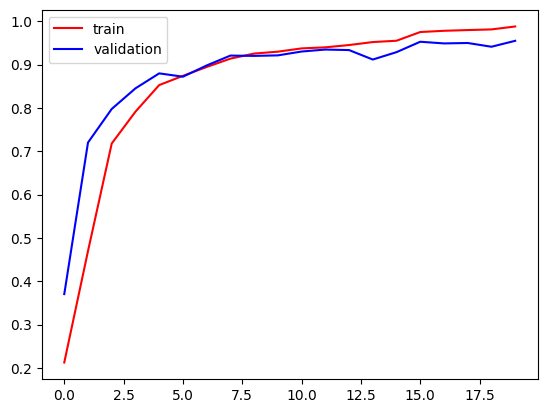

In [41]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

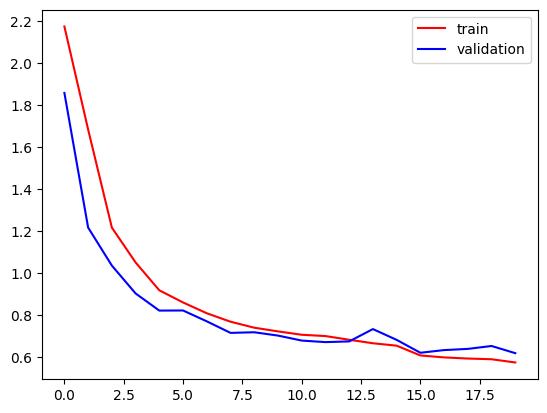

In [42]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

conf_matrix = confusion_matrix(true_classes, predicted_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=validation_generator.class_indices.keys(), yticklabels=validation_generator.class_indices.keys())
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

Valid 20%, Train 80%

In [31]:
from tensorflow.keras import models, Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout
import tensorflow as tf

# Tải mô hình VGG16
base_model = tf.keras.applications.VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

# Xây dựng mô hình
model = Sequential()

# Sử dụng base_model thay cho conv_base
model.add(base_model) 
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.1))

model.add(Dense(120, activation='relu'))
model.add(Dropout(0.1))

model.add(Dense(32, activation='relu'))
model.add(Dropout(0.1))

model.add(Dense(10, activation='softmax'))

optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)
model.compile(optimizer=optimizer,
              loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
              metrics=['accuracy'])

model.build((None, 224, 224, 3))
model.summary(expand_nested=True)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ input_layer_4 (InputLayer) │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ block1_conv1 (Conv2D)      │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ block1_conv2 (Conv2D)      │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ block1_pool (MaxPooling2D) │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ block2_conv1 (Conv2D)      │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ block2_conv2 (Conv2D)      │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ block2_pool (MaxPooling2D) │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ block3_conv1 (Conv2D)      │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ block3_conv2 (Conv2D)      │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ block3_conv3 (Conv2D)      │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ block3_pool (MaxPooling2D) │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ block4_conv1 (Conv2D)      │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ block4_conv2 (Conv2D)      │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ block4_conv3 (Conv2D)      │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ block4_pool (MaxPooling2D) │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ block5_conv1 (Conv2D)      │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ block5_conv2 (Conv2D)      │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ block5_conv3 (Conv2D)      │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ block5_pool (MaxPooling2D) │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 120)            │        30,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 120)            │             

 Total params: 21,172,514 (80.77 MB)

 Trainable params: 6,457,826 (24.63 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [32]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.utils import class_weight
import numpy as np

early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5)

model_checkpoint = ModelCheckpoint('animal_classifier_myteam_epoch_{epoch:02d}.keras', 
                                   monitor='val_loss', 
                                   save_best_only=True, 
                                   save_weights_only=False, 
                                   mode='auto', 
                                   save_freq='epoch')

class_weights_array = class_weight.compute_class_weight(class_weight='balanced',
                                                        classes=np.unique(train_generator.classes),
                                                        y=train_generator.classes)

class_weights = dict(enumerate(class_weights_array))

history = model.fit(
    train_generator,
    epochs=20,
    validation_data=validation_generator,
    callbacks=[early_stopping, reduce_lr, model_checkpoint],
    class_weight=class_weights  
)

model.save('animal_classifier_final_myteam.h5')

Epoch 1/20


/opt/conda/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


261/261 ━━━━━━━━━━━━━━━━━━━━ 306s 1s/step - accuracy: 0.3034 - loss: 2.0104 - val_accuracy: 0.7336 - val_loss: 1.2180 - learning_rate: 1.0000e-04
Epoch 2/20
261/261 ━━━━━━━━━━━━━━━━━━━━ 260s 970ms/step - accuracy: 0.5933 - loss: 1.4596 - val_accuracy: 0.7720 - val_loss: 1.0867 - learning_rate: 1.0000e-04
Epoch 3/20
261/261 ━━━━━━━━━━━━━━━━━━━━ 259s 967ms/step - accuracy: 0.6624 - loss: 1.3184 - val_accuracy: 0.8159 - val_loss: 0.9975 - learning_rate: 1.0000e-04
Epoch 4/20
261/261 ━━━━━━━━━━━━━━━━━━━━ 274s 1s/step - accuracy: 0.6967 - loss: 1.2266 - val_accuracy: 0.8227 - val_loss: 0.9708 - learning_rate: 1.0000e-04
Epoch 5/20
261/261 ━━━━━━━━━━━━━━━━━━━━ 272s 1s/step - accuracy: 0.7197 - loss: 1.1990 - val_accuracy: 0.8248 - val_loss: 0.9533 - learning_rate: 1.0000e-04
Epoch 6/20
261/261 ━━━━━━━━━━━━━━━━━━━━ 293s 1s/step - accuracy: 0.7467 - loss: 1.1359 - val_accuracy: 0.8330 - val_loss: 0.9306 - learning_rate: 1.0000e-04
Epoch 7/20
261/261 ━━━━━━━━━━━━━━━━━━━━ 290s 1s/step - accuracy

In [43]:
model.save('animal_classifier_final_myteam1.keras')

In [33]:
import numpy as np
from sklearn.metrics import classification_report, accuracy_score
from tensorflow.keras import models

# Tải mô hình đã huấn luyện
my_model = models.load_model('/kaggle/working/animal_classifier_final_myteam.h5')

# Dự đoán trên tập dữ liệu kiểm tra (validation_generator)
predictions = my_model.predict(validation_generator)

# Chuyển đổi các xác suất thành nhãn lớp dự đoán
predicted_classes = np.argmax(predictions, axis=1)

# Lấy nhãn thật từ validation_generator
true_classes = validation_generator.classes

# Đánh giá độ chính xác (accuracy)
accuracy = accuracy_score(true_classes, predicted_classes)
print(f"Accuracy: {accuracy:.4f}")

# Tạo báo cáo phân loại, bao gồm precision, recall, và f1-score
# `target_names` tương ứng với tên các lớp (class labels)
class_labels = list(validation_generator.class_indices.keys())  # Lấy tên các lớp từ generator
report = classification_report(true_classes, predicted_classes, target_names=class_labels)

# Hiển thị báo cáo phân loại
print("Classification Report:\n", report)

66/66 ━━━━━━━━━━━━━━━━━━━━ 17s 246ms/step
Accuracy: 0.8639
Classification Report:
               precision    recall  f1-score   support

   butterfly       0.91      0.96      0.94       361
         cat       0.74      0.88      0.80       333
     chicken       0.91      0.90      0.91       517
         cow       0.78      0.86      0.82       373
         dog       0.84      0.79      0.82       517
    elephant       0.87      0.83      0.85       289
       horse       0.86      0.91      0.89       524
       sheep       0.85      0.76      0.80       364
      spider       0.95      0.95      0.95       517
    squirrel       0.90      0.74      0.82       372

    accuracy                           0.86      4167
   macro avg       0.86      0.86      0.86      4167
weighted avg       0.87      0.86      0.86      4167



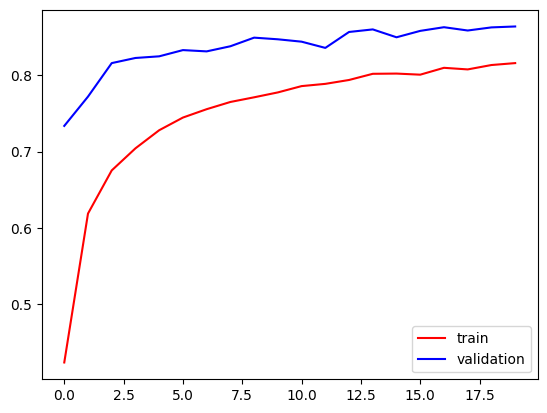

In [34]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

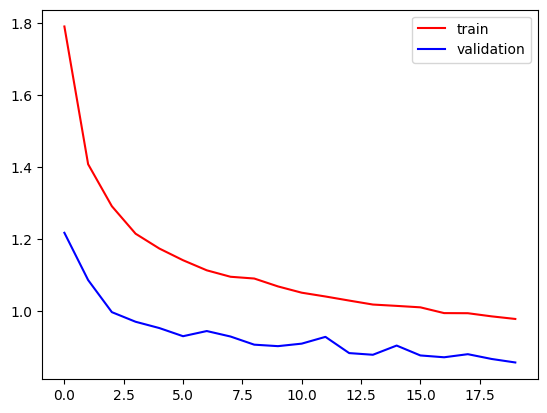

In [35]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()

Valid 20%, train 100%

In [14]:
from tensorflow.keras import models, Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout
import tensorflow as tf

# Tải mô hình VGG16
base_model = tf.keras.applications.VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

# Xây dựng mô hình
model = Sequential()

# Sử dụng base_model thay cho conv_base
model.add(base_model) 
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.1))

model.add(Dense(120, activation='relu'))
model.add(Dropout(0.1))

model.add(Dense(32, activation='relu'))
model.add(Dropout(0.1))

model.add(Dense(10, activation='softmax'))

optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)
model.compile(optimizer=optimizer,
              loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
              metrics=['accuracy'])

model.build((None, 224, 224, 3))
model.summary(expand_nested=True)


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ input_layer (InputLayer)   │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ block1_conv1 (Conv2D)      │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ block1_conv2 (Conv2D)      │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ block1_pool (MaxPooling2D) │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ block2_conv1 (Conv2D)      │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ block2_conv2 (Conv2D)      │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ block2_pool (MaxPooling2D) │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ block3_conv1 (Conv2D)      │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ block3_conv2 (Conv2D)      │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ block3_conv3 (Conv2D)      │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ block3_pool (MaxPooling2D) │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ block4_conv1 (Conv2D)      │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ block4_conv2 (Conv2D)      │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ block4_conv3 (Conv2D)      │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ block4_pool (MaxPooling2D) │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ block5_conv1 (Conv2D)      │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ block5_conv2 (Conv2D)      │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ block5_conv3 (Conv2D)      │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ block5_pool (MaxPooling2D) │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 120)            │        30,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 120)            │             

 Total params: 21,172,514 (80.77 MB)

 Trainable params: 6,457,826 (24.63 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [15]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.utils import class_weight
import numpy as np

early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5)

model_checkpoint = ModelCheckpoint('animal_classifier_epoch_{epoch:02d}.keras', 
                                   monitor='val_loss', 
                                   save_best_only=True, 
                                   save_weights_only=False, 
                                   mode='auto', 
                                   save_freq='epoch')

class_weights_array = class_weight.compute_class_weight(class_weight='balanced',
                                                        classes=np.unique(train_generator.classes),
                                                        y=train_generator.classes)

class_weights = dict(enumerate(class_weights_array))

history = model.fit(
    train_generator,
    epochs=20,
    validation_data=validation_generator,
    callbacks=[early_stopping, reduce_lr, model_checkpoint],
    class_weight=class_weights  
)

model.save('animal_classifier_final.h5')


Epoch 1/20


/opt/conda/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1731917009.659118     155 service.cc:145] XLA service 0x7ff6f00112e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1731917009.659192     155 service.cc:153]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1731917009.659198     155 service.cc:153]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1731917035.260479     155 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


326/326 ━━━━━━━━━━━━━━━━━━━━ 431s 1s/step - accuracy: 0.3139 - loss: 1.9826 - val_accuracy: 0.7413 - val_loss: 1.1810 - learning_rate: 1.0000e-04
Epoch 2/20
326/326 ━━━━━━━━━━━━━━━━━━━━ 370s 1s/step - accuracy: 0.6177 - loss: 1.4014 - val_accuracy: 0.8152 - val_loss: 1.0079 - learning_rate: 1.0000e-04
Epoch 3/20
326/326 ━━━━━━━━━━━━━━━━━━━━ 340s 1s/step - accuracy: 0.6871 - loss: 1.2592 - val_accuracy: 0.8311 - val_loss: 0.9439 - learning_rate: 1.0000e-04
Epoch 4/20
326/326 ━━━━━━━━━━━━━━━━━━━━ 320s 960ms/step - accuracy: 0.7176 - loss: 1.1930 - val_accuracy: 0.8452 - val_loss: 0.9067 - learning_rate: 1.0000e-04
Epoch 5/20
326/326 ━━━━━━━━━━━━━━━━━━━━ 335s 1s/step - accuracy: 0.7299 - loss: 1.1589 - val_accuracy: 0.8512 - val_loss: 0.8884 - learning_rate: 1.0000e-04
Epoch 6/20
326/326 ━━━━━━━━━━━━━━━━━━━━ 346s 1s/step - accuracy: 0.7567 - loss: 1.1189 - val_accuracy: 0.8699 - val_loss: 0.8607 - learning_rate: 1.0000e-04
Epoch 7/20
326/326 ━━━━━━━━━━━━━━━━━━━━ 334s 1s/step - accuracy: 0

In [16]:
my_model = models.load_model('/kaggle/working/animal_classifier_final.h5')
loss, accuracy = my_model.evaluate(validation_generator)
print(f"Validation Loss: {loss:.4f}, Validation Accuracy: {accuracy:.4f}")


66/66 ━━━━━━━━━━━━━━━━━━━━ 17s 249ms/step - accuracy: 0.9303 - loss: 0.7118
Validation Loss: 0.7512, Validation Accuracy: 0.9138


In [25]:
import numpy as np
from sklearn.metrics import classification_report, accuracy_score
from tensorflow.keras import models

# Tải mô hình đã huấn luyện
my_model = models.load_model('/kaggle/working/animal_classifier_final.h5')
predictions = my_model.predict(validation_generator)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = validation_generator.classes
accuracy = accuracy_score(true_classes, predicted_classes)
print(f"Accuracy: {accuracy:.4f}")
class_labels = list(validation_generator.class_indices.keys()) 
report = classification_report(true_classes, predicted_classes, target_names=class_labels)

print("Classification Report:\n", report)

66/66 ━━━━━━━━━━━━━━━━━━━━ 17s 252ms/step
Accuracy: 0.9138
Classification Report:
               precision    recall  f1-score   support

   butterfly       0.96      0.98      0.97       361
         cat       0.89      0.91      0.90       333
     chicken       0.94      0.95      0.94       517
         cow       0.81      0.92      0.86       373
         dog       0.93      0.84      0.88       517
    elephant       0.90      0.90      0.90       289
       horse       0.94      0.93      0.93       524
       sheep       0.85      0.85      0.85       364
      spider       0.97      0.97      0.97       517
    squirrel       0.92      0.88      0.90       372

    accuracy                           0.91      4167
   macro avg       0.91      0.91      0.91      4167
weighted avg       0.92      0.91      0.91      4167



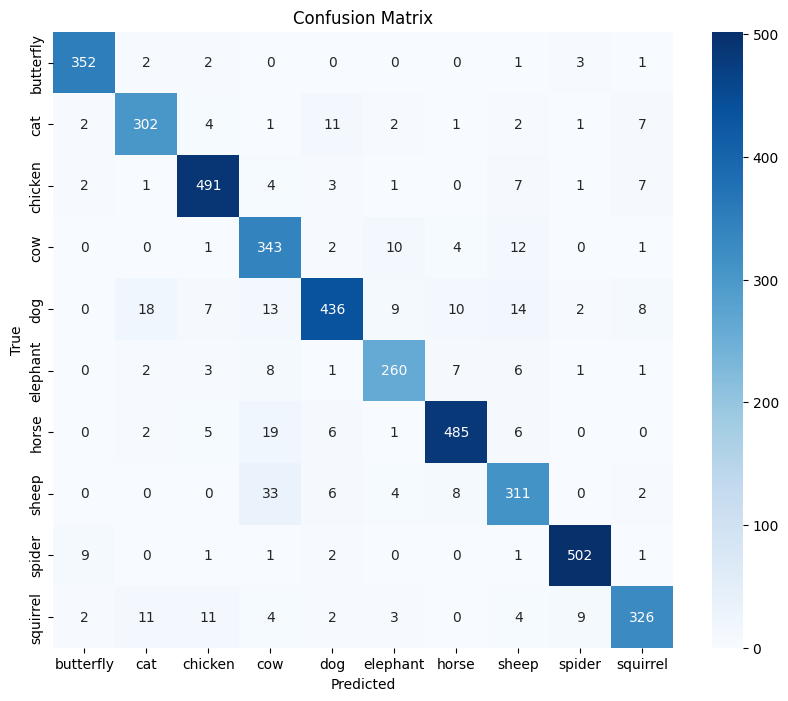

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

conf_matrix = confusion_matrix(true_classes, predicted_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=validation_generator.class_indices.keys(), yticklabels=validation_generator.class_indices.keys())
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

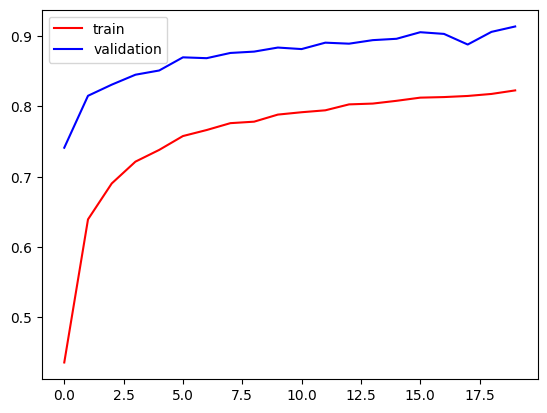

In [27]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

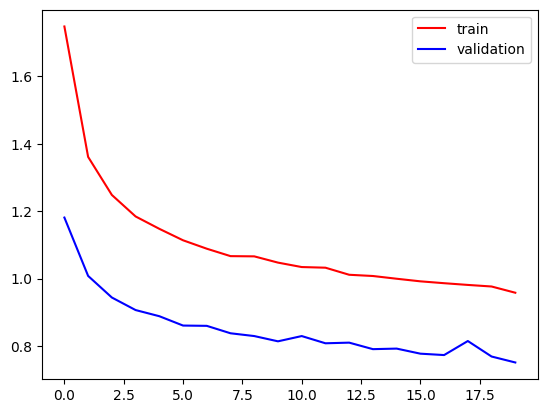

In [28]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()

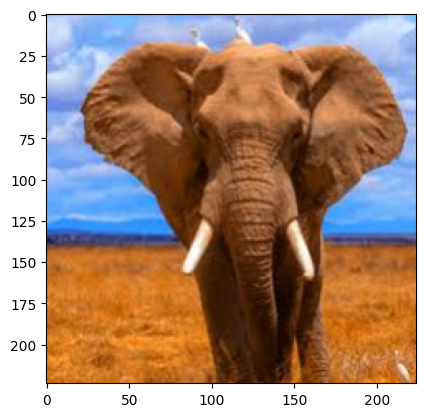

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Class: 0, Animal: butterfly, Probability: 0.0000
Class: 1, Animal: cat, Probability: 0.0000
Class: 2, Animal: chicken, Probability: 0.0000
Class: 3, Animal: cow, Probability: 0.0000
Class: 4, Animal: dog, Probability: 0.0000
Class: 5, Animal: elephant, Probability: 1.0000
Class: 6, Animal: horse, Probability: 0.0000
Class: 7, Animal: sheep, Probability: 0.0000
Class: 8, Animal: spider, Probability: 0.0000
Class: 9, Animal: squirrel, Probability: 0.0000
Hình ảnh được đưa vào là của 
Class: 5 
Animal: elephant


In [21]:
def predictor(img, model, class_indices):
    image = cv2.imread(img)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = cv2.resize(image, (224, 224))

    plt.imshow(image)
    plt.show()
    
    image = image.reshape(1, 224, 224, 3)  # Reshape the image for prediction
    
    dict_class = {v: k for k, v in class_indices.items()}
    probabilities = model.predict(image)
    clas = probabilities.argmax()
    name = dict_class[clas]
    
    for i in range(probabilities.shape[1]):
        print(f'Class: {i}, Animal: {dict_class[i]}, Probability: {float(probabilities[0][i]):.4f}')
    
    print(f'Hình ảnh được đưa vào là của \nClass: {clas} \nAnimal: {name}')
class_indices = train_generator.class_indices
my_model = models.load_model('/kaggle/input/trained-model/animal_classifier_final.h5')
predictor('/kaggle/input/animals/animals/inf/elephant.jpg', my_model, class_indices)

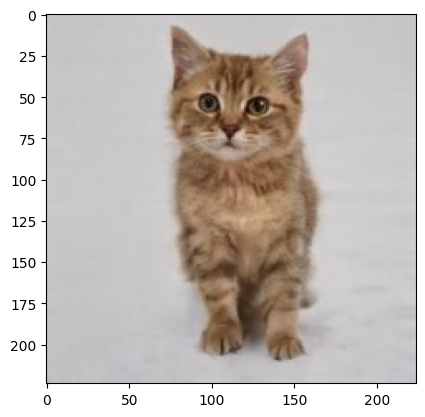

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Class: 0, Animal: butterfly, Probability: 0.0000
Class: 1, Animal: cat, Probability: 1.0000
Class: 2, Animal: chicken, Probability: 0.0000
Class: 3, Animal: cow, Probability: 0.0000
Class: 4, Animal: dog, Probability: 0.0000
Class: 5, Animal: elephant, Probability: 0.0000
Class: 6, Animal: horse, Probability: 0.0000
Class: 7, Animal: sheep, Probability: 0.0000
Class: 8, Animal: spider, Probability: 0.0000
Class: 9, Animal: squirrel, Probability: 0.0000
Hình ảnh được đưa vào là của 
Class: 1 
Animal: cat


In [22]:
predictor('/kaggle/input/animals/animals/inf/cat.jpg', my_model, class_indices)

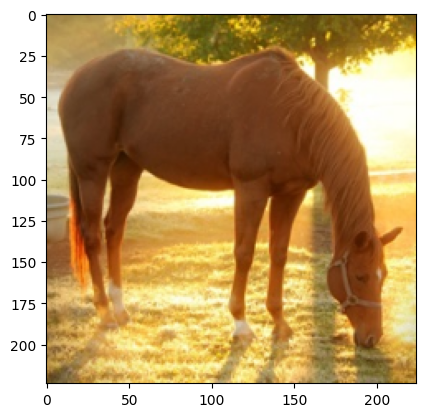

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
Class: 0, Animal: butterfly, Probability: 0.0000
Class: 1, Animal: cat, Probability: 0.0000
Class: 2, Animal: chicken, Probability: 0.0000
Class: 3, Animal: cow, Probability: 0.0000
Class: 4, Animal: dog, Probability: 0.0000
Class: 5, Animal: elephant, Probability: 0.0000
Class: 6, Animal: horse, Probability: 1.0000
Class: 7, Animal: sheep, Probability: 0.0000
Class: 8, Animal: spider, Probability: 0.0000
Class: 9, Animal: squirrel, Probability: 0.0000
Hình ảnh được đưa vào là của 
Class: 6 
Animal: horse


In [23]:
predictor('/kaggle/input/animals/animals/inf/horse.jpg', my_model, class_indices)

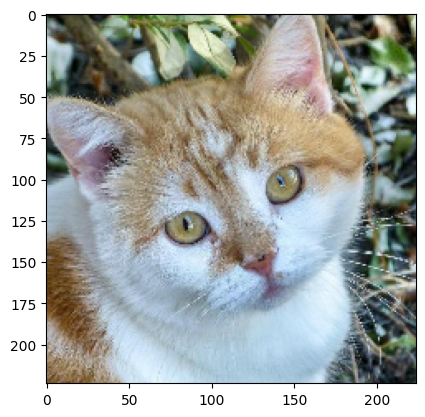

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Class: 0, Animal: butterfly, Probability: 0.0000
Class: 1, Animal: cat, Probability: 1.0000
Class: 2, Animal: chicken, Probability: 0.0000
Class: 3, Animal: cow, Probability: 0.0000
Class: 4, Animal: dog, Probability: 0.0000
Class: 5, Animal: elephant, Probability: 0.0000
Class: 6, Animal: horse, Probability: 0.0000
Class: 7, Animal: sheep, Probability: 0.0000
Class: 8, Animal: spider, Probability: 0.0000
Class: 9, Animal: squirrel, Probability: 0.0000
Hình ảnh được đưa vào là của 
Class: 1 
Animal: cat


In [24]:
predictor('/kaggle/input/animals/animals/train/cat/cat10.jpg', my_model, class_indices)